In [1]:
from pepnets.PeptideNetwork import PeptideNetwork
import random
import pandas as pd
import numpy as np
from pepnets.util import get_database
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

sus_scrofa = pd.read_csv("../data/sus_scrofa.gz", sep="\t")
sus_scrofa["Entry Name"] = sus_scrofa["Entry Name"].apply(lambda x: x.split("_")[0])
database_dict = get_database(sus_scrofa, key_col="Entry Name", value_col="Sequence")

datamatrix = pd.read_csv("../data/data.csv")

pnet = PeptideNetwork(
    datamatrix=datamatrix,
    protein_database=database_dict,
)

_ = pnet.create_network(distance_cutoff=4)
resolution = 0.8

clusters = pnet.get_clusters(resolution=resolution, random_seed=42)
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.remove_small_clusters(threshold=3)
clusters.reindex()
mapping = clusters.get_mapping(database_dict)

from pepnets.FeatureMatrix import FeatureMatrix

design = pd.read_csv("../data/design.csv")
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
datamatrix = fm.get_normalized_dm()
topn = (
    fm.get_topn_de("P. aeruginosa", "S. aureus")
    .groupby("Cluster")
    .mean(numeric_only=True)
    #.drop(columns=["id", "Start", "End"])
)
topn = (
    topn.merge(mapping, left_index=True, right_on="ID_single")
    .rename(columns={"name_combined": "Cluster"})[
        ["Cluster"] + design["sample"].tolist()
    ]
    .drop_duplicates(subset="Cluster")
)
design = design.sort_values(["group", "day"])

/Users/erikhartman/dev/peptide-networks/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading peptides...
Merged 41 clusters

Removed 0 clusters
Removed 857 clusters
Removed 303 clusters


nopython is set for njit and is ignored
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice


In [2]:
from dpks import QuantMatrix

groups = ["P. aeruginosa", "S. aureus", "Double infection"]
design = design[design["group"].isin(groups)]
topn = topn.set_index("Cluster")[design["sample"]].reset_index()


qm = QuantMatrix(
    topn,
    design,
)

qm.compare(
    method="ttest",
    min_samples_per_group=15,
    level="Cluster",
    comparisons=[("S. aureus", "P. aeruginosa")],
    multiple_testing_correction_method="fdr_tsbh",
)


compared_data = qm.to_df()
compared_data["Protein"] = compared_data["Cluster"].apply(lambda x: x.split(" (")[0])
compared_data.sort_values("CorrectedPValueS. aureus-P. aeruginosa")

,Cluster,DEScoreS. aureus-P. aeruginosa,GroupS. aureusMean,GroupP. aeruginosaMean,GroupS. aureusStdev,GroupP. aeruginosaStdev,Log2FoldChangeS. aureus-P. aeruginosa,PValueS. aureus-P. aeruginosa,GroupS. aureusRepCounts,GroupP. aeruginosaRepCounts,...,Sample 13 Day 2,Sample 14 Day 2,Sample 15 Day 2,Sample 16 Day 2,Sample 66 Day 2,Sample 67 Day 2,Sample 68 Day 2,Sample 69 Day 2,Sample 70 Day 2,Protein
356,HBA (0-16),1.292634,10.738981,16.181039,1.648764,1.453170,-5.442058,2.423457e-18,24,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300798,HBA
233,F1RX36 (480-497),0.779930,14.646921,12.211029,1.101287,1.202195,2.435892,7.476358e-13,38,33,...,14.515826,13.982833,11.982345,14.171207,13.460183,14.809750,14.633672,12.333525,14.828372,F1RX36
715,TYB4 (26-44),1.020063,9.765639,15.248618,3.337044,1.935667,-5.482979,2.741619e-11,33,33,...,NaN,11.161760,10.218412,7.106806,1.296913,7.276319,9.665919,1.283119,11.864991,TYB4
245,F1RX36 (638-657),0.863014,8.249227,12.704451,2.613406,1.879498,-4.455225,2.691139e-10,28,33,...,NaN,11.586503,7.626531,10.934788,NaN,4.240132,9.220707,NaN,7.696170,F1RX36
716,TYB4 (32-44),0.671092,8.114744,10.802552,1.626268,1.167538,-2.687808,3.695749e-10,30,33,...,9.775583,9.233486,10.149082,8.121298,6.972179,7.710077,8.360154,NaN,9.386756,TYB4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,VTNC (111-127),NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,14,...,NaN,NaN,NaN,NaN,NaN,NaN,0.537254,NaN,16.402260,VTNC
739,VTNC (206-220),NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,1,...,NaN,1.734583,NaN,8.384330,NaN,6.991028,9.482185,NaN,7.681277,VTNC
740,VTNC (220-235),NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VTNC
741,VTNC (282-294),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VTNC


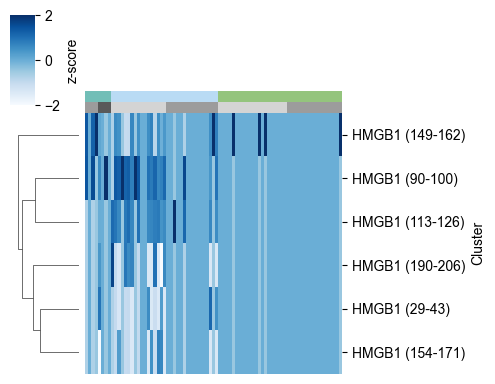

In [39]:
compared_data["Repcount"] = (
    compared_data["GroupP. aeruginosaRepCounts"]
    + compared_data["GroupS. aureusRepCounts"]
)
plot_df = compared_data[compared_data["Repcount"] > 3]
plot_df = (
    plot_df[plot_df["Cluster"].str.contains("HMGB1")]
    .set_index("Cluster")[design["sample"]]
    .fillna(0)
)

import seaborn as sns
from pepnets.palette import group_palette, day_palette
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(plot_df.values)
plot_df = pd.DataFrame(X, index=plot_df.index, columns=plot_df.columns)
group = pd.Series(design["group"])
day = pd.Series(design["day"])
group_colors = group.map(group_palette)
day_colors = day.map(day_palette)
g = sns.clustermap(
    plot_df,
    col_colors=[group_colors.values, day_colors.values],
    figsize=(5, 5),
    col_cluster=False,
    cmap="Blues",
    vmin=-2,
    vmax=2,
    cbar_kws={"label": "z-score"},
)
g.ax_heatmap.set_xticks([])
plot_df.to_csv("source_data/4c.csv")
plt.savefig("figures/main_figures/4c1.svg", bbox_inches="tight")

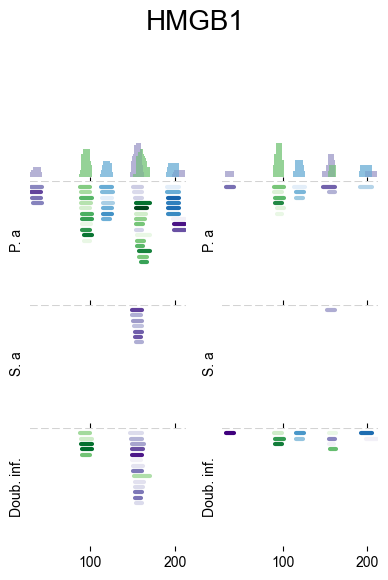

In [40]:
groups = ["P. aeruginosa", "S. aureus", "Double infection"]

protein = "HMGB1"

days = ["Day 1", "Day 2"]

hmgb1_design = design.copy()

hmgb1_design["day"] = hmgb1_design.apply(
    lambda x: (
        x["day"]
        if x["group"] != "Double infection"
        else f"Day {int(x['day'].split(' ')[-1])-1}"
    ),
    axis=1,
)

from pepnets.PeptiGrams import PeptiGram

pg = PeptiGram(datamatrix, hmgb1_design)

pg.plot_peptigram(
    protein,
    groups=groups,
    days=days,
    cmaps=["Purples", "Greens", "Blues"] * 5,
    figsize=(4,5),
    size_factor=1.5,
    annotate=False,
)
plt.savefig("figures/main_figures/4c2.png", bbox_inches="tight", dpi=300)

356          HBA (0-16)
233    F1RX36 (480-497)
715        TYB4 (26-44)
245    F1RX36 (638-657)
716        TYB4 (32-44)
108       APOC3 (20-35)
240    F1RX36 (599-619)
403       HMGN2 (30-42)
234    F1RX36 (500-516)
231    F1RX36 (453-482)
Name: Cluster, dtype: object


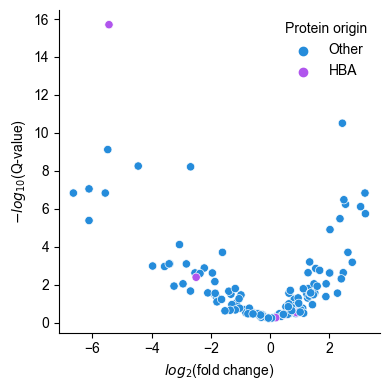

In [41]:
plot_df = compared_data.copy()
print(plot_df.sort_values("-Log10CorrectedPValueS. aureus-P. aeruginosa", ascending=False)["Cluster"][0:10])
plot_df["color"] = plot_df["Protein"].apply(lambda x: "HBA" if x == "HBA" else "Other")

import seaborn as sns
from pepnets.palette import group_palette, day_palette
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(4, 4))
sns.scatterplot(
    plot_df,
    x="Log2FoldChangeS. aureus-P. aeruginosa",
    y="-Log10CorrectedPValueS. aureus-P. aeruginosa",
    hue="color",
    palette=["#258cdb", "#b055ed"]
)
plt.xlabel(r"$log_2$(fold change)")
plt.ylabel(r"$-log_{10}$(Q-value)")
plt.legend(frameon=False, title="Protein origin")
sns.despine()
plt.tight_layout()
plot_df.to_csv("source_data/4a.csv")
plt.savefig("figures/main_figures/4a1.svg", bbox_inches="tight")

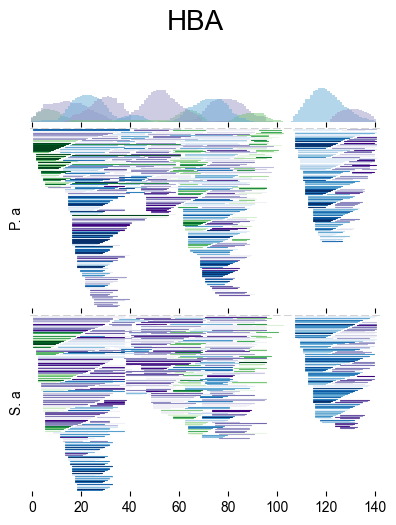

In [42]:
groups = ["P. aeruginosa", "S. aureus"]

protein = "HBA"

design["day"] = "Day 1"
days = ["Day 1"]


from pepnets.PeptiGrams import PeptiGram

pg = PeptiGram(datamatrix, design)

pg.plot_peptigram(
    protein,
    groups=groups,
    days=days,
    cmaps=["Purples", "Greens", "Blues"] * 5,
    figsize=(4,5),
    size_factor=0.4,
    annotate=False,
)
plt.savefig("figures/main_figures/4a2.png", bbox_inches="tight", dpi=300)

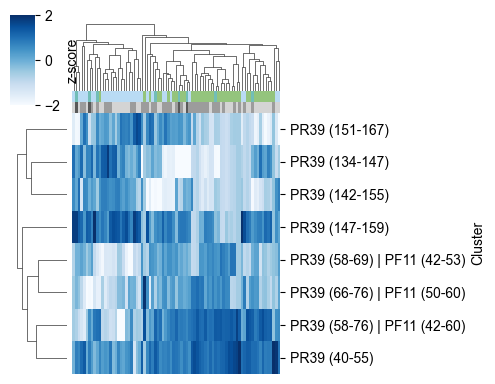

In [42]:
compared_data["Repcount"] = (
    compared_data["GroupP. aeruginosaRepCounts"]
    + compared_data["GroupS. aureusRepCounts"]
)
plot_df = compared_data[compared_data["Repcount"] > 30].copy()
plot_df = (
    plot_df[plot_df["Cluster"].str.contains("PR39") & ~plot_df["Cluster"].str.contains("PG") ] #remove PG cluster
    .set_index("Cluster")[design["sample"]]
    .fillna(0)
)

import seaborn as sns
from pepnets.palette import group_palette, day_palette
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(plot_df.values)
plot_df = pd.DataFrame(X, index=plot_df.index, columns=plot_df.columns)

group_colors = group.map(group_palette)
day_colors = day.map(day_palette)
g = sns.clustermap(
    plot_df,
    col_colors=[group_colors.values, day_colors.values],
    figsize=(5, 5),
    cmap="Blues",
    vmin=-2,
    vmax=2,
    cbar_kws={"label": "z-score"},
)
g.ax_heatmap.set_xticks([])
plot_df.to_csv("source_data/4b.csv")
plt.savefig("figures/main_figures/4b1.svg", bbox_inches="tight")

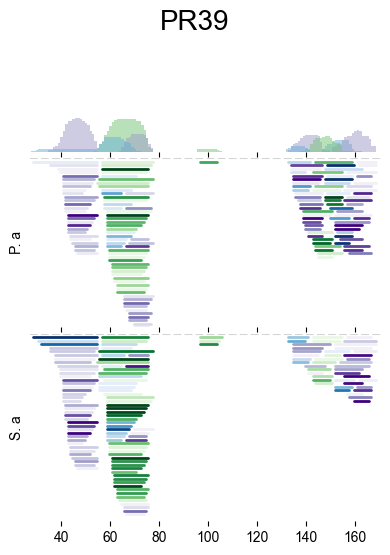

In [44]:
groups = ["P. aeruginosa", "S. aureus"]

protein = "PR39"

days = ["Day 1"]


from pepnets.PeptiGrams import PeptiGram

pg = PeptiGram(datamatrix, design)

pg.plot_peptigram(
    protein,
    groups=groups,
    days=days,
    cmaps=["Blues", "Purples", "Greens"] * 5,
    figsize=(4, 5),
    size_factor=1,
    annotate=False,
)
plt.savefig("figures/main_figures/4b2.png", bbox_inches="tight", dpi=300)

[]

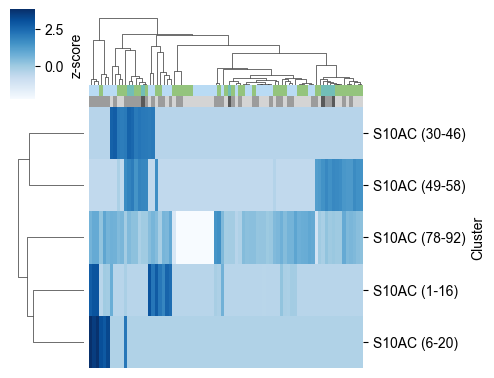

In [51]:
compared_data["Repcount"] = (
    compared_data["GroupP. aeruginosaRepCounts"]
    + compared_data["GroupS. aureusRepCounts"]
)
plot_df = compared_data[compared_data["Repcount"] > 5].copy()
plot_df = (
    plot_df[plot_df["Cluster"].str.contains("S10AC")] #remove PG cluster
    .set_index("Cluster")[design["sample"]]
    .fillna(0)
)


import seaborn as sns
from pepnets.palette import group_palette, day_palette
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(plot_df.values.T).T
plot_df = pd.DataFrame(X, index=plot_df.index, columns=plot_df.columns)

group_colors = group.map(group_palette)
day_colors = day.map(day_palette)
g = sns.clustermap(
    plot_df,
    col_colors=[group_colors.values, day_colors.values],
    figsize=(5, 5),
    cmap="Blues",
    #vmin=-2,
    #vmax=2,
    cbar_kws={"label": "z-score"},
)
g.ax_heatmap.set_xticks([])

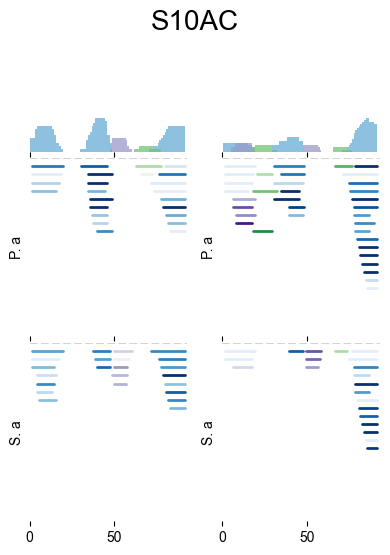

In [31]:
groups = ["P. aeruginosa", "S. aureus"]

protein = "S10AC"

days = ["Day 1", "Day 2"]


from pepnets.PeptiGrams import PeptiGram

pg = PeptiGram(datamatrix, design)

pg.plot_peptigram(
    protein,
    groups=groups,
    days=days,
    cmaps=["Blues", "Purples", "Greens"] * 5,
    figsize=(4, 5),
    size_factor=1,
    annotate=False,
)
